# Fenòmen del món petit

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

from utils import draw_graph, draw_graphs

Definim les funcions per construïr les xarxes

In [2]:
# a) Anell regular
def anell_regular(N, k):
    G = nx.Graph()
    for i in range(N):
        for j in range(1,k//2+1):
            G.add_edge(i,(i + j)%N )
            G.add_edge(i,(i - j)%N )
    return G

# b) Xarxa aleatòria d'Erdős–Rényi
def erdos_renyi(N, k):
    p = k/N # Chance of connection between a pair of nodes
    B = nx.Graph()
    for i in range(N):
        for j in range(N):
            if j != i: # Avoid auto-loops
                if np.random.random() < p: 
                    B.add_edge(i,j)
    return B

# c) Xarxa de Watts–Strogatz
def watts_strogatz(N, k, beta):
    G = anell_regular(N, k) 
    for node in range(N):
        for neighbour in list(G.neighbors(node)): # List won't be modified during the iteration
            if np.random.random() < beta:
                # Rewiring: remove the current edge
                G.remove_edge(node,neighbour)

                # Choose randomly a new neighbour different from the current one
                new_neighbour = np.random.randint(0,N)
                while (new_neighbour == node):
                    new_neighbour = np.random.randint(0,N)

                # Reconnects the node to the new random neighbour
                G.add_edge(node, new_neighbour)
    return G

Funcions per $L$ i $C$

In [3]:
# L = 〈d(i,j)〉(mitjana de les distàncies mínimes entre tots els parells de nodes)
def L(G):
    try:
        return nx.average_shortest_path_length(G)
    except nx.NetworkXError:
        return float('inf')

# C (proporció de triangles tancats sobre el nombre de camins de longitud 2). 
def C(G):
    try:
        return nx.average_clustering(G)
    except nx.NetworkXError:
        return 0

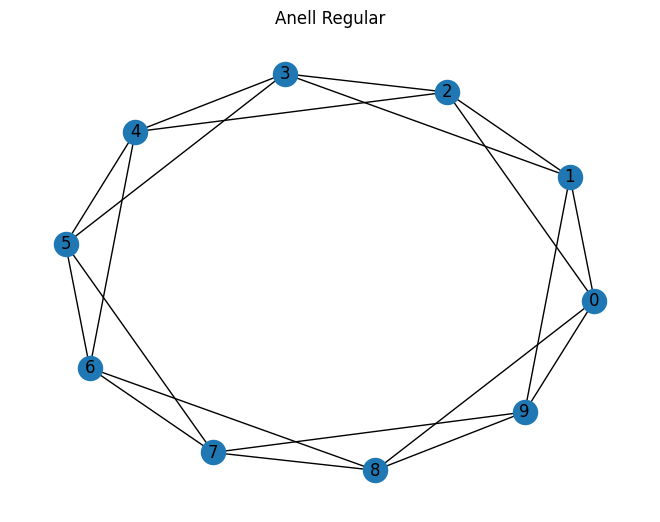

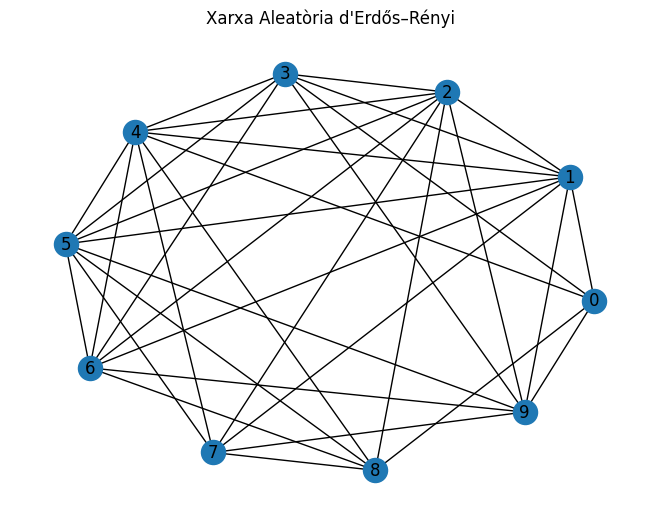

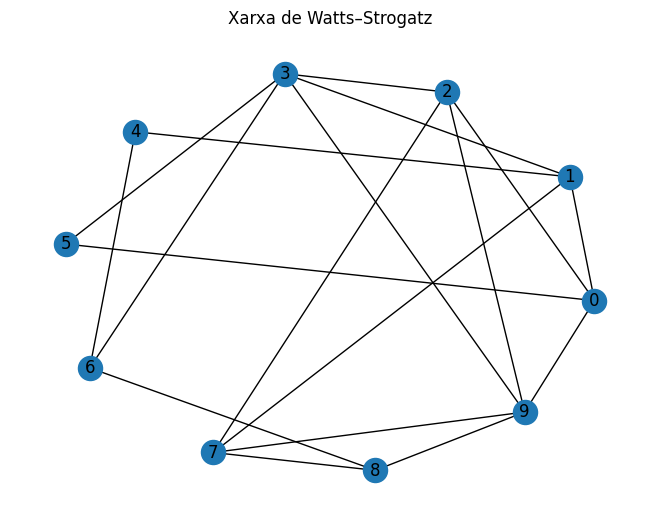

In [4]:
# Exemples d'ús
N = 10
k = 4
beta = 0.3

graphs = {
    "Anell Regular": anell_regular(N, k),
    "Xarxa Aleatòria d'Erdős–Rényi": erdos_renyi(N, k),
    "Xarxa de Watts–Strogatz": watts_strogatz(N, k, beta)
}

# Garanteix que la posició dels nodes sigui la mateixa a cada graf
pos = nx.spring_layout(graphs["Anell Regular"], seed=123)

# draw_graphs(graphs)

draw_graph(graphs["Anell Regular"], "Anell Regular", pos=pos)
draw_graph(graphs["Xarxa Aleatòria d'Erdős–Rényi"], "Xarxa Aleatòria d'Erdős–Rényi", pos=pos)
draw_graph(graphs["Xarxa de Watts–Strogatz"], "Xarxa de Watts–Strogatz", pos=pos)

## Estudi del problema

Estudiar la proporció entre $k$ i $N$  ($k/N$). Mirar si pels valors que ens donen una proporció p tenen els mateixos resultats de $L$ i $C$.

In [5]:
# Com que volem fer moltes simulacions i per xarxes grans, i el càclul de L és molt costós,
# comprovem que una L aproximada per 100 nodes a l'atzar és prou bona
def L_approx(G, n_samples=None):
    """
    Estima el camí mig (L) fent servir un mostreig de nodes font.
    Si n_samples és None, calcula el valor exacte (lent).
    """
    nodes = list(G.nodes())
    N = len(nodes)
    
    # Si la xarxa és petita o no especifiquem mostres, fem el càlcul exacte
    if n_samples is None or n_samples >= N:
        try:
            return nx.average_shortest_path_length(G)
        except (nx.NetworkXError, nx.NetworkXNoPath):
            return float('inf')

    # Triem n_samples nodes a l'atzar com a punts de partida
    sources = random.sample(nodes, n_samples)
    lengths = []

    for source in sources:
        # Calculem les distàncies des de 'source' a TOTS els altres nodes
        # Això és un sol BFS (molt ràpid en xarxes no pesades)
        path_lengths = nx.single_source_shortest_path_length(G, source)
        
        # Ignorem la distància al propi node (que és 0)
        distancies = [v for k, v in path_lengths.items() if k != source]
        lengths.extend(distancies)

    # Si no hem trobat camins (xarxa desconnectada), retornem inf
    if not lengths:
        return float('inf')
        
    return np.mean(lengths)

Considerem que amb `n_samples=50` obtenim una bona aproximació de L. A partir d'ara calculem L amproximant-la amb `L_aprox`.

In [6]:
p = 0.01
Ns = range(1000, 10001, 500)
ks = [N*p for N in Ns]

beta = 0.3
Ls = []
Cs = []

n_samples = 50

for i in range(len(Ns)):
    N = Ns[i]
    k = int(ks[i])
    G0 = anell_regular(N, k)
    L0 = L_approx(G0, n_samples=n_samples)
    C0 = C(G0)

    G = watts_strogatz(N, k, beta)
    L_norm = L_approx(G, n_samples=n_samples)/L0
    C_norm = C(G)/C0

    print(f"N={N}, k={k}, L_norm={L_norm:.5f}, C_norm={C_norm:.5f}")
    Ls.append(L_norm)
    Cs.append(C_norm)

N=1000, k=10, L_norm=0.06723, C_norm=0.13764
N=1500, k=15, L_norm=0.05823, C_norm=0.13213
N=2000, k=20, L_norm=0.05738, C_norm=0.13319
N=2500, k=25, L_norm=0.05416, C_norm=0.13400
N=3000, k=30, L_norm=0.05515, C_norm=0.12971
N=3500, k=35, L_norm=0.05303, C_norm=0.12795
N=4000, k=40, L_norm=0.05368, C_norm=0.13009
N=4500, k=45, L_norm=0.05241, C_norm=0.12843
N=5000, k=50, L_norm=0.05273, C_norm=0.12947
N=5500, k=55, L_norm=0.05148, C_norm=0.13026
N=6000, k=60, L_norm=0.05170, C_norm=0.12927
N=6500, k=65, L_norm=0.05073, C_norm=0.12892
N=7000, k=70, L_norm=0.05095, C_norm=0.12995
N=7500, k=75, L_norm=0.04986, C_norm=0.12791
N=8000, k=80, L_norm=0.05011, C_norm=0.12789
N=8500, k=85, L_norm=0.04911, C_norm=0.12874
N=9000, k=90, L_norm=0.04933, C_norm=0.12975
N=9500, k=95, L_norm=0.04854, C_norm=0.12778
N=10000, k=100, L_norm=0.04853, C_norm=0.12985


Fixant N i K, però variant $\beta$, per veure com afecta a L i C

In [ ]:
# Fixem una N prou gran i fem algunes simulacions per veure com varien L i L_approx
N = 2000
k = int(0.05 * N) 
betes = [10**(-k) for k in range(10, -1, -1)]

Ls = []
L_approxs = []
Cs = []

n_samples = 50


G0 = anell_regular(N, k)
L0 = L_approx(G0, n_samples=n_samples)
C0 = C(G0)

for beta in betes:
    G = watts_strogatz(N, k, beta)

    Ls.append(L(G))
    L_approxs.append(L_approx(G, n_samples=n_samples)/L0)
    Cs.append(C(G)/C0)


plt.figure(figsize=(8,5))
plt.plot(betes, L_approxs, marker='o', label='L', color='red')
plt.plot(betes, Cs, marker='o', label='C', color='blue')
plt.xscale('log')
plt.xlabel('beta')
plt.ylabel('L (vermell) i C (blau)')
plt.title(f'L i C vs beta (N={N}, k={k})')
plt.legend()
plt.tight_layout()
plt.show()

Coses que podriem fer:
+ Calcular $L(\beta)$ i $C(\beta)$ per als valors de $\beta$ que tenim i normalitzar-los.
    + Representar-ho en un gràfic amb eix $x$ logarítmc. Ens hauria de sortir que L cau en picat mentre C es manté alt.
    + Reflexió: Per què unes poques "dreceres" tenen un impacte tan massiu en la distància mitjana però gairebé no afecten a la clusterització local?

+ Calcular `mixing_time` per a cada valor de beta.
    + Hipòtesi: En un anell regular el temps és molt alt (perquè està atrapat localment). A mida que s'augmenta $\beta$, hauria de decreixer similarment a L.
    + Comprovar si el "col·lapse" del temps de mescla coincideix amb l'aparició del fenòmen del mon petit. Això demostraria que aquest tipus de xarxes no només són curtes en distància, sinó també eficients per a processos de difusió.

+ Fixant un $\beta$ baix i variant N, comparar com creix el temps de cobertura en l'anell regular en comparació a la xarxa del mon petit.
    + Hauriem de veure que en l'anell regular el temps de cobertura creix de forma quadràtica i que en una aleatòria, molt més ràpidament $\approx N\log N$.
    + Mirar que fa la xarxa de Watts-Strogatz.

+ Visualització de la Distribució estacionària.
    + A la xarxa Erdos-renyi els graus no son iguals, fer histograma de la probabilitat estacionària de cada node.
    + Dibuixar el graf de manera que el color o mida del node depengui del seu valor a la distribució estàcionària.
    + Podem identificar els nodes centrals que actuen "com a imants" per al camí aleatori.

+ Què passa si la xarxa no és connexa?



Sembla que fer el graf dirigit complica molt les cose si hauriem de modificar moltes funcions. Si fos el cas que ho fessim, podriem mirar el següent:
+ El `cover_time` es bloquejarà fàcilment en simulació. Estudiar a mida que augmentem $\beta$ aquest bloqueig.
+ `stacionari_distribution` deixaria de funcionar, i el problema es convertiriaen l'algorisme de PageRank de Google.
+ Com calculem L? Ara el camí de A a B té longitud diferent al de B a A.